In [1]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path("D:/loan-default-prediction/data/processed/modeling_datset.csv")
model_df = pd.read_csv(DATA_PATH)

print(model_df.shape)
print(model_df.head())


(1348099, 13)
   loan_amnt  term_months  int_rate grade sub_grade  emp_length_years  \
0     3600.0           36     13.99     C        C4              10.0   
1    24700.0           36     11.99     C        C1              10.0   
2    20000.0           60     10.78     B        B4              10.0   
3    10400.0           60     22.45     F        F1               3.0   
4    11950.0           36     13.44     C        C3               4.0   

  home_ownership  annual_inc verification_status  issue_year  \
0       MORTGAGE     55000.0        Not Verified        2015   
1       MORTGAGE     65000.0        Not Verified        2015   
2       MORTGAGE     63000.0        Not Verified        2015   
3       MORTGAGE    104433.0     Source Verified        2015   
4           RENT     34000.0     Source Verified        2015   

              purpose    dti  default_flag  
0  debt_consolidation   5.91             0  
1      small_business  16.06             0  
2    home_improvement  10.7

In [2]:
analysis_df = model_df.copy()

analysis_df["dti_band"] = pd.cut(
    analysis_df["dti"],
    bins=[-float("inf"), 10, 20, 30, float("inf")],
    labels=["0-10", "10-20", "20-30", "30+"]
)

analysis_df["income_band"] = pd.cut(
    analysis_df["annual_inc"],
    bins=[-float("inf"), 30000, 60000, 100000, float("inf")],
    labels=["Below 30k", "30k-60k", "60k-100k", "100k+"]
)

analysis_df["interest_rate_band"] = pd.cut(
    analysis_df["int_rate"],
    bins=[-float("inf"), 10, 15, 20, 25, float("inf")],
    labels=["Below 10%", "10%-15%", "15%-20%", "20%-25%", "25%+"]
)

display(
    analysis_df[
        [
            "dti", "dti_band",
            "annual_inc", "income_band",
            "int_rate", "interest_rate_band"
        ]
    ].head()
)

,dti,dti_band,annual_inc,income_band,int_rate,interest_rate_band
0,5.91,0-10,55000.0,30k-60k,13.99,10%-15%
1,16.06,10-20,65000.0,60k-100k,11.99,10%-15%
2,10.78,10-20,63000.0,60k-100k,10.78,10%-15%
3,25.37,20-30,104433.0,100k+,22.45,20%-25%
4,10.20,10-20,34000.0,30k-60k,13.44,10%-15%


In [3]:
def default_rate_by(column):
    summary = (
        analysis_df.groupby(column, observed=True)["default_flag"]
        .agg(
            loan_count="size",
            bad_loans="sum",
            default_rate="mean"
        )
        .assign(default_rate=lambda table: table["default_rate"] * 100)
        .sort_values("default_rate", ascending=False)
    )
    
    return summary

In [4]:
grade_summary = default_rate_by("grade")
display(grade_summary)

,loan_count,bad_loans,default_rate
grade,,,
G,9326,4632,49.667596
F,32306,14585,45.146412
E,94192,36199,38.431077
D,201657,61264,30.380299
C,382323,85805,22.443065
B,393102,52661,13.396269
A,235193,14214,6.043547


grade
A     6.043547
B    13.396269
C    22.443065
D    30.380299
E    38.431077
F    45.146412
G    49.667596
Name: default_flag, dtype: float64

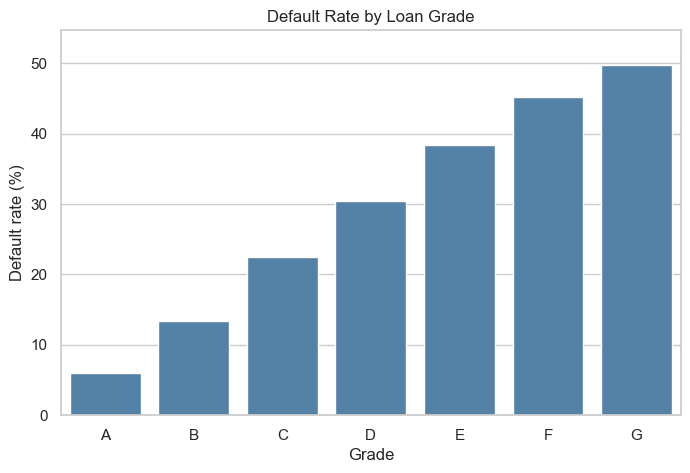

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

grade_order = ["A", "B", "C", "D", "E", "F", "G"]

grade_chart_data = (
    analysis_df.groupby("grade", observed=True)["default_flag"]
    .mean()
    .mul(100)
    .reindex(grade_order)
)
display(grade_chart_data)
plt.figure(figsize=(8,5))
sns.barplot(
    x=grade_chart_data.index,
    y=grade_chart_data.values,
    color="steelblue"
)

plt.title("Default Rate by Loan Grade")
plt.xlabel("Grade")
plt.ylabel("Default rate (%)")
plt.ylim(0, grade_chart_data.max() + 5)
plt.show()

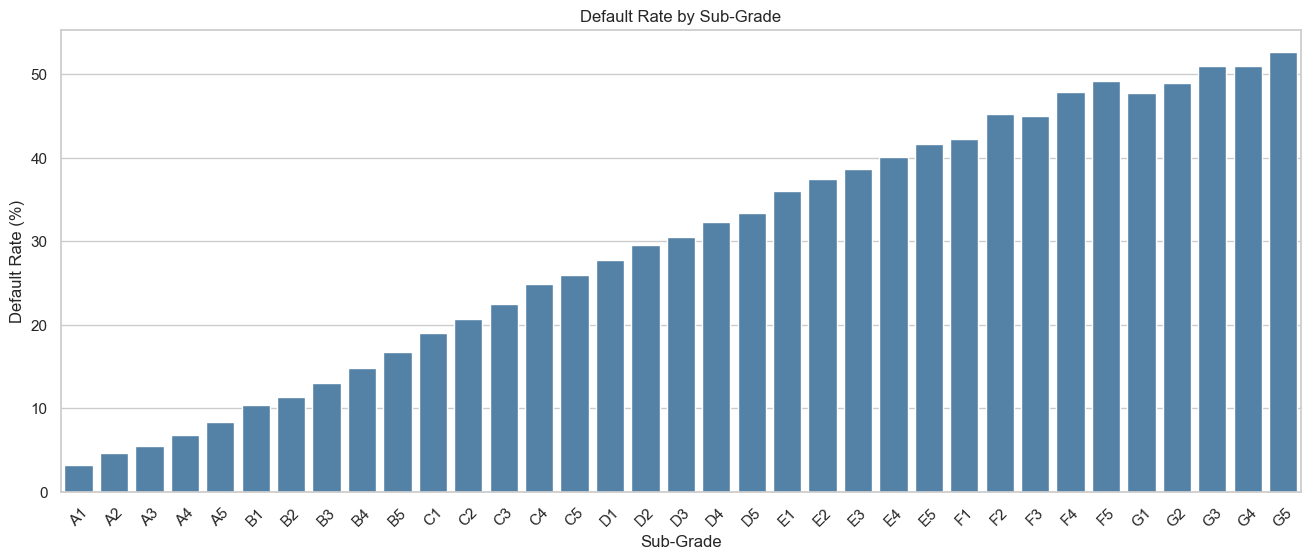

In [11]:
subgrade_order = [
    f"{grade}{number}"
    for grade in ["A", "B", "C", "D", "E", "F", "G"]
    for number in range(1,6)
]

subgrade_chart_data = (
    analysis_df.groupby("sub_grade", observed=True)["default_flag"]
    .mean()
    .mul(100)
    .reindex(subgrade_order)
)

plt.figure(figsize=(16,6))
sns.barplot(
    x = subgrade_chart_data.index,
    y = subgrade_chart_data.values,
    color = "steelblue"
)

plt.title("Default Rate by Sub-Grade")
plt.xlabel("Sub-Grade")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=45)
plt.show()

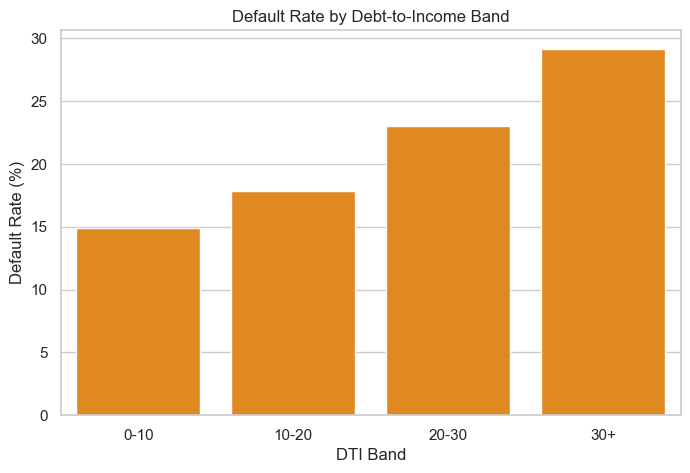

In [14]:
dti_order = ["0-10", "10-20", "20-30", "30+"]

dti_chart_data = (
    analysis_df.groupby("dti_band", observed=True)["default_flag"]
    .mean()
    .mul(100)
    .reindex(dti_order)
)

plt.figure(figsize=(8,5))
sns.barplot(
    x = dti_chart_data.index,
    y = dti_chart_data.values,
    color = "darkorange"
)

plt.title("Default Rate by Debt-to-Income Band")
plt.xlabel("DTI Band")
plt.ylabel("Default Rate (%)")
plt.show()

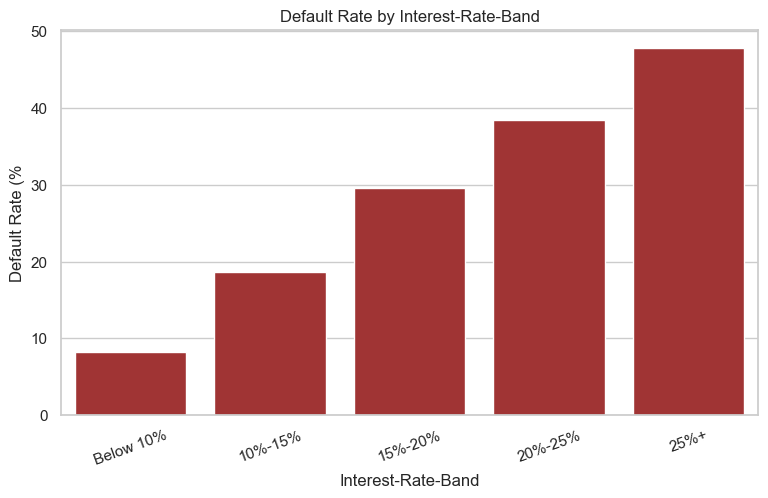

In [17]:
interest_order = [
    "Below 10%",
    "10%-15%",
    "15%-20%",
    "20%-25%",
    "25%+"
]

interest_chart_data = (
    analysis_df.groupby("interest_rate_band", observed=True)["default_flag"]
    .mean()
    .mul(100)
    .reindex(interest_order)
)

plt.figure(figsize=(9,5))
sns.barplot(
    x = interest_chart_data.index,
    y = interest_chart_data.values,
    color="firebrick"
)

plt.title("Default Rate by Interest-Rate-Band")
plt.xlabel("Interest-Rate-Band")
plt.ylabel("Default Rate (%")
plt.xticks(rotation=20)
plt.show()

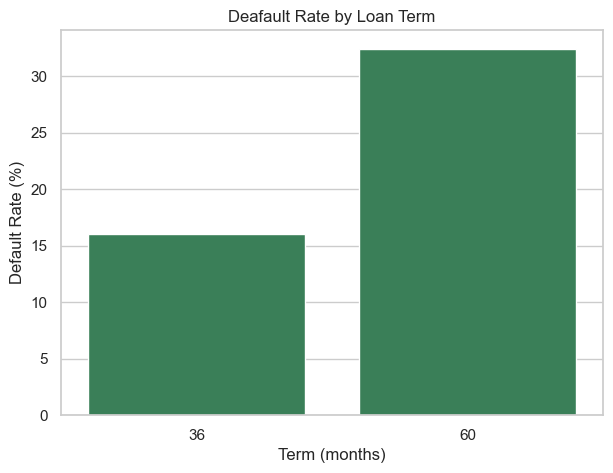

In [19]:
term_order = [36,60]

term_chart_data = (
    analysis_df.groupby("term_months", observed=True)["default_flag"]
    .mean()
    .mul(100)
    .reindex(term_order)
)

plt.figure(figsize=(7,5))
sns.barplot(
    x=term_chart_data.index,
    y=term_chart_data.values,
    color="seagreen"
)

plt.title("Deafault Rate by Loan Term")
plt.xlabel("Term (months)")
plt.ylabel("Default Rate (%)")
plt.show()

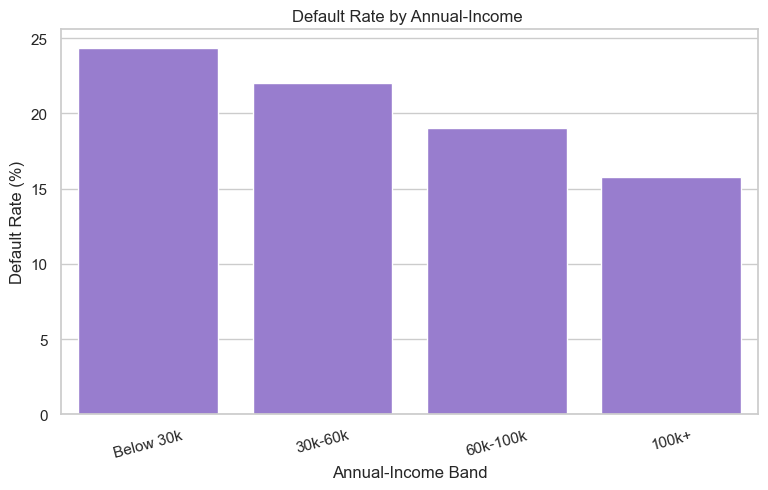

In [23]:
income_order = [
    "Below 30k",
    "30k-60k",
    "60k-100k",
    "100k+"
]

income_chart_data = (
    analysis_df.groupby("income_band", observed=True)["default_flag"]
    .mean()
    .mul(100)
    .reindex(income_order)
)

plt.figure(figsize=(9,5))
sns.barplot(
    x=income_chart_data.index,
    y=income_chart_data.values,
    color= "mediumpurple"
)

plt.title("Default Rate by Annual-Income ")
plt.xlabel("Annual-Income Band")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=15)
plt.show()

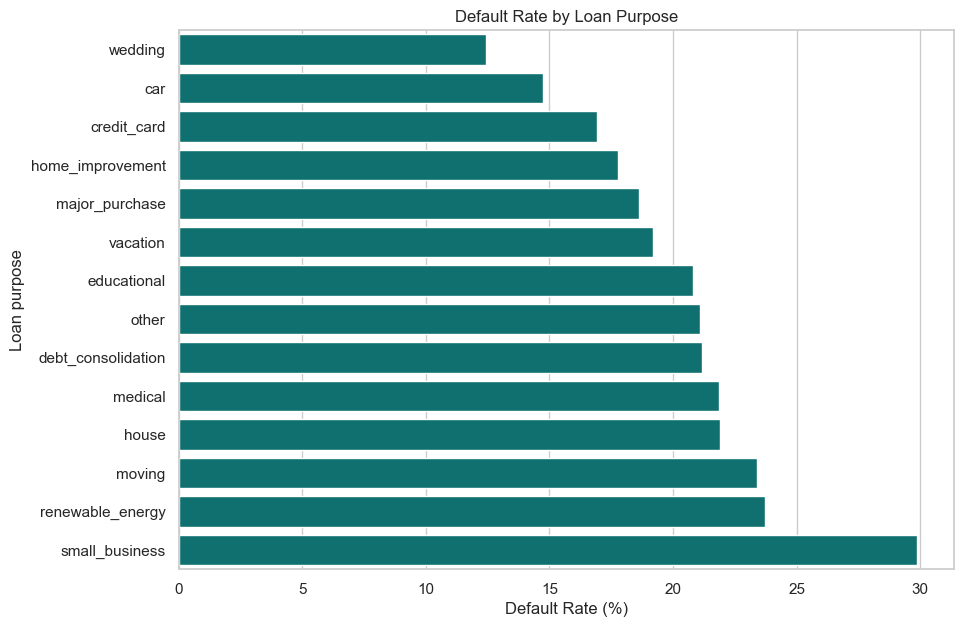

In [25]:
purpose_chart_data = (
    analysis_df.groupby("purpose", observed=True)["default_flag"]
    .mean()
    .mul(100)
    .sort_values(ascending=True)
)

plt.figure(figsize=(10,7))
sns.barplot(
    x=purpose_chart_data.values,
    y=purpose_chart_data.index,
    color="teal"
)

plt.title("Default Rate by Loan Purpose")
plt.xlabel("Default Rate (%)")
plt.ylabel("Loan purpose")
plt.show()

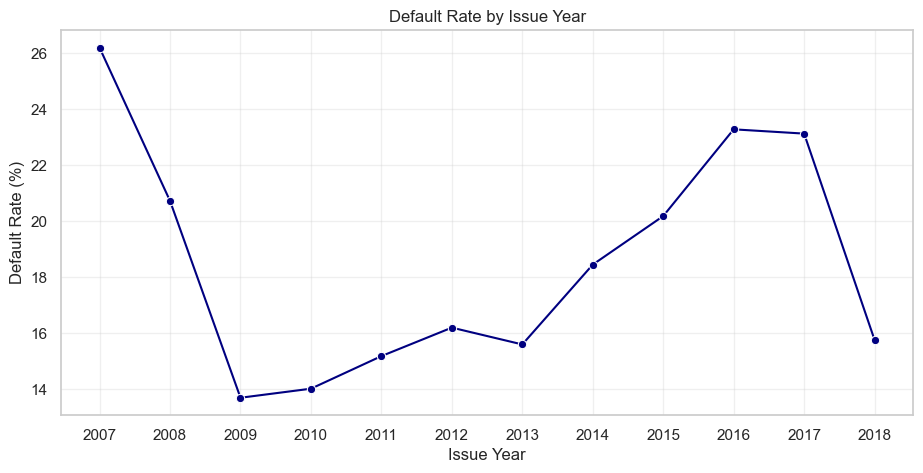

In [32]:
year_chart_data = (
    analysis_df.groupby("issue_year", observed=True)["default_flag"]
    .mean()
    .mul(100)
    .sort_index()
)
plt.figure(figsize=(11,5))
sns.lineplot(
    x= year_chart_data.index,
    y= year_chart_data.values,
    marker = "o",
    color="navy"
)

plt.title("Default Rate by Issue Year")
plt.xlabel("Issue Year")
plt.ylabel("Default Rate (%)")
plt.xticks(year_chart_data.index)
plt.grid(True, alpha=0.3)
plt.show()

In [34]:
exploration_columns= [
    "grade",
    "dti_band",
    "interest_rate_band",
    "term_months",
    "income_band",
    "purpose",
    "issue_year",
]

for column in exploration_columns:
    print(f"\n--- {column} ---")
    display(default_rate_by(column))


--- grade ---


,loan_count,bad_loans,default_rate
grade,,,
G,9326,4632,49.667596
F,32306,14585,45.146412
E,94192,36199,38.431077
D,201657,61264,30.380299
C,382323,85805,22.443065
B,393102,52661,13.396269
A,235193,14214,6.043547



--- dti_band ---


,loan_count,bad_loans,default_rate
dti_band,,,
30+,128307,37438,29.178455
20-30,409035,94309,23.056462
10-20,563348,100676,17.871014
0-10,247033,36866,14.923512



--- interest_rate_band ---


...

,loan_count,bad_loans,default_rate
income_band,,,
Below 30k,99768,24299,24.355505
30k-60k,519686,114515,22.035421
60k-100k,478169,91121,19.056233
100k+,250472,39425,15.740282



--- purpose ---


,loan_count,bad_loans,default_rate
purpose,,,
small_business,15577,4652,29.864544
renewable_energy,936,222,23.717949
moving,9526,2229,23.399118
house,7298,1599,21.910112
medical,15614,3411,21.845779
debt_consolidation,781442,165327,21.156657
other,78301,16508,21.082745
educational,423,88,20.803783
vacation,9084,1744,19.198591



--- issue_year ---


,loan_count,bad_loans,default_rate
issue_year,,,
2007,603,158,26.202322
2016,293105,68252,23.285853
2017,169321,39169,23.132984
2008,2393,496,20.727121
2015,375546,75804,20.185011
2014,223103,41162,18.449774
2012,53367,8644,16.197275
2018,56318,8874,15.756952
2013,134804,21024,15.595976


## Feature Exploration Summary

### Main observations

1. **Grade:** When moving for A to G grade the default rate inclines.
2. **DTI:** Higher the DTI bands higher the default rate.
3. **Interest rate:** Interest band is also directly proportional to the default rate.
4. **Loan term:** 60-month loan have higher default rate than 36-month loan.
5. **Income:** - Income shows a clear inverse association with default rate: the rate decreases from 24.36% for borrowers earning below 30k to 15.74% for borrowers earning 100k or more. This is an observed relationship, not proof that income alone causes lower default risk.
6. **Purpose:** small_business tends to have highest default rate while weeding have the lowest default rate.
7. **Issue year:**  The historical trend shows a sharp decline in defaults after 2007–2009, followed by a gradual rise peaking in 2016–2017, and then a significant improvement in 2018.

These are observed associations in historical data. They do not prove that any single feature causes default.